# New Zealand Crash Analysis System

## Introduction

This notebook presents a structured analysis of crash severity using a curated subset of the New Zealand Crash Analysis System dataset. After preparing and engineering key features — including environmental conditions, road characteristics, vehicle involvement, and injury indicators — the workflow narrows to a correlation‑filtered set of predictors that carry the strongest signal. Exploratory visualisations establish the real‑world patterns behind severe crashes, setting up a focused modelling phase.

Three interpretable baseline classifiers — Logistic Regression, a calibrated Linear SVM, and Bernoulli Naive Bayes — are trained and evaluated on an imbalanced binary target. The notebook is organised to support a clear presentation narrative: understanding the data, identifying meaningful patterns, and assessing how well simple, fast models can predict severe crash outcomes.


## Libraries

In [1]:
# libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

pd.set_option("display.max_columns", None)


## Functions

In [2]:
def load_data(file_path):
    try:
        df = pd.read_csv(file_path)
        print("Dataset loaded successfully.")
        display(df.head())
        return df
    except Exception as e:
        print(f"Failed to load data: {e}")
        return None


In [3]:
def inspect_dataframe(df):
    # Does a brief inspection of a dataframe
    print("-" * 30)
    # Shape of the dataframe
    # Basic shape
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    
    print("\n" +"-" * 30)
    # Display the first few rows
    print("\nHead of the DataFrame:")
    display(df.head())
    
    print("\n" +"-" * 30)
    # Display the last few rows
    print("\nTail of the DataFrame:")
    display(df.tail())
    
    print("\n" +"-" * 30)
    # DataFrame info
    print("\nDataFrame Info:")
    df.info()
    
    print("\n" +"-" * 30)
    # Statistical description
    print("\nStatistical Description:")
    display(df.describe())
    
    print("\n" +"-" * 30)
    # Check for duplicates
    duplicates = df.duplicated().sum()
    print(f"\nNumber of duplicate rows: {duplicates}")

    print("\n" +"-" * 30)
    # Check for null values
    print("\nNull Values Count:")
    missing = (
    df.isnull()
      .sum()
      .reset_index()
      .rename(columns={"index": "column", 0: "number_missing"})
    )

    missing = missing[missing["number_missing"] > 0]
    missing["percent_missing"] = (missing["number_missing"] / len(df)) * 100
    
    display(missing)



In [4]:
def replace_string_nulls(df):
    return df.apply(
        lambda col: col.replace(
            to_replace=["Null", "null", "NULL", " Null ", " null "],
            value=pd.NA
        )
        if col.dtype == "object" or pd.api.types.is_string_dtype(col)
        else col
    )


In [5]:
def combine_weather(weatherA, weatherB):
    """
    Combine weatherA and weatherB into a single label.

    Rules:
    - If both are present → "A / B"
    - If only one is present → that one
    - If both are missing → ""
    """
    a = weatherA if pd.notnull(weatherA) else None
    b = weatherB if pd.notnull(weatherB) else None

    if a and b:
        return f"{a} / {b}"
    if a:
        return a
    if b:
        return b
    return ""


In [6]:
def show_countplot(df, col, title, figsize=(10,6)):
    data = df[col].dropna()

    plt.figure(figsize=figsize)
    sns.countplot(
        data=df,
        y=col,
        order=data.value_counts().index
    )
    plt.title(title)
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()


In [7]:
def plot_lower_corr(df, cols, figsize=(10, 8), cmap="coolwarm"):
    """
    Plot a strict lower-triangle correlation heatmap for selected columns.
    
    Parameters
    ----------
    df : pandas.DataFrame
        The dataframe containing your data.
    cols : list
        List of column names to include in the correlation matrix.
    figsize : tuple
        Figure size for the plot.
    cmap : str
        Colormap for the heatmap.
    """
    
    corr = df[cols].corr()
    
    # Strict upper triangle mask (diagonal included)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
    
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        cmap=cmap,
        square=True
    )
    plt.title("Correlation Heatmap (Strict Lower Triangle)")
    plt.tight_layout()
    plt.show()


In [8]:
def evaluate_model(name, model, X_test, y_test, y_proba=None):
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    if y_proba is not None:
        roc = roc_auc_score(y_test, y_proba)
    else:
        roc = np.nan
    
    # Reports
    cls_report = classification_report(y_test, y_pred, output_dict=False)
    cls_report_dict = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    
    # Print nicely
    print(f"=== {name} ===")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("ROC-AUC  :", roc)
    print("\nClassification report:\n", cls_report)
    print("Confusion matrix:\n", cm)
    
    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc,
        "classification_report": cls_report_dict,
        "confusion_matrix": cm
    }


In [9]:
def plot_confusion_matrix(cm, labels=[0, 1], title="Confusion Matrix"):
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()


In [10]:
def summarise_model_results(results_df):
    """
    Produce a clean comparison table with:
      - Model
      - Accuracy
      - Precision
      - Recall
      - F1-Score
      - ROC-AUC

    Ignores nested structures like classification_report and confusion_matrix.
    Returns a tidy DataFrame ready for display or export.
    """

    cols = ["model", "accuracy", "precision", "recall", "f1", "roc_auc"]

    # Filter only the columns we need (in case extra fields exist)
    summary = results_df[cols].copy()

    # Rename for presentation clarity
    summary = summary.rename(columns={
        "model": "Model",
        "accuracy": "Accuracy",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1-Score",
        "roc_auc": "ROC-AUC"
    })

    return summary


# Load and inspect the data

In [11]:
# A csv has been downloaded from Kaggle:
# https://www.kaggle.com/datasets/neonninja/nzta-crash-analysis-system-cas?resource=download

file_path = r"C:\Users\caled\repos\DataScience\Mini Project 2\Crash_Analysis_System_CAS_data_Kaggle.csv"
# Load the Kaggle dataset
df = load_data(file_path)


Dataset loaded successfully.


,X,Y,OBJECTID,advisorySpeed,animals,areaUnitID,bicycle,bridge,bus,carStationWagon,cliffBank,crashDirectionDescription,crashDistance,crashFinancialYear,crashLocation1,crashLocation2,crashSeverity,crashSHDescription,crashYear,debris,directionRoleDescription,ditch,easting,fatalCount,fence,flatHill,guardRail,holiday,houseOrBuilding,intersectionMidblock,junctionType,kerb,light,meshblockId,minorInjuryCount,moped,motorcycle,northing,NumberOfLanes,objectThrownOrDropped,otherObject,otherVehicleType,outdatedLocationDescription,overBank,parkedVehicle,pedestrian,phoneBoxEtc,postOrPole,region,roadCharacter,roadCurvature,roadLane,roadMarkings,roadSurface,roadworks,schoolBus,seriousInjuryCount,slipOrFlood,speedLimit,strayAnimal,streetLight,suv,taxi,temporarySpeedLimit,tlaId,tlaName,trafficControl,trafficIsland,trafficSign,train,tree,truck,unknownVehicleType,urban,vanOrUtility,vehicle,waterRiver,weatherA,weatherB
0,2.442007e+06,5077559.0,1001,NaN,0.0,597000.0,0.0,0.0,0.0,1.0,1.0,East,4600.0,2004,WAITANGI WHARF - OWENGA ROAD,NORTH ROAD,Minor Crash,No,2004,0.0,East,0.0,2442006.0,0.0,0.0,Hill Road,0.0,NaN,0.0,Midblock,Nil (Default),0.0,Twilight,2717400.0,1.0,0.0,0.0,5077558.0,2.0,0.0,1.0,0.0,Current location,0.0,0.0,NaN,0.0,0.0,Wellington Region,Nil,Straight,2-way,NaN,Unsealed,0.0,0.0,0.0,0.0,100.0,0.0,NaN,0.0,0.0,NaN,67.0,Chatham Islands Territory,Nil,0.0,0.0,0.0,0.0,0.0,0.0,Open,0.0,0.0,0.0,Fine,Null
1,1.883922e+06,5774047.0,1002,NaN,NaN,540410.0,0.0,NaN,0.0,2.0,NaN,Null,NaN,2005,SH 30A,TAREWA ROAD,Non-Injury Crash,Yes,2004,NaN,East,NaN,1883922.0,0.0,NaN,Flat,NaN,NaN,NaN,Intersection,T Junction,NaN,Overcast,1231900.0,0.0,0.0,0.0,5774047.0,4.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Bay of Plenty Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Off,0.0,0.0,NaN,24.0,Rotorua District,Give way,NaN,NaN,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Light rain,Null
2,1.760533e+06,5915602.0,1003,NaN,NaN,520201.0,0.0,NaN,0.0,2.0,NaN,South,200.0,2010,SH 1N,GREENLANE OFF NBD,Minor Crash,Yes,2009,NaN,North,NaN,1760533.0,0.0,NaN,Flat,NaN,NaN,NaN,Midblock,Nil (Default),NaN,Overcast,613000.0,1.0,0.0,0.0,5915602.0,4.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Auckland Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,100.0,NaN,Off,1.0,0.0,NaN,76.0,Auckland,Nil,NaN,NaN,NaN,NaN,1.0,0.0,Open,0.0,NaN,NaN,Light rain,Null
3,1.754996e+06,5935872.0,1004,NaN,NaN,507101.0,0.0,NaN,0.0,1.0,NaN,Null,NaN,2016,CARLISLE ROAD,LIMMER PLACE,Minor Crash,No,2016,NaN,West,NaN,1754996.0,0.0,NaN,Flat,NaN,NaN,NaN,Intersection,T Junction,NaN,Overcast,159601.0,1.0,0.0,0.0,5935872.0,2.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Auckland Region,Nil,Curved,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Null,1.0,0.0,NaN,76.0,Auckland,Give way,NaN,NaN,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null
4,1.764335e+06,5914721.0,1005,NaN,NaN,520303.0,0.0,NaN,0.0,1.0,NaN,South,200.0,2015,MOUNT WELLINGTON HIGHWAY,ELLERSLIE-PANMURE HIGHWAY,Minor Crash,No,2014,NaN,North,NaN,1764335.0,0.0,NaN,Flat,NaN,NaN,NaN,Midblock,Nil (Default),NaN,Bright sun,627400.0,1.0,0.0,0.0,5914721.0,4.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Auckland Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Null,0.0,0.0,NaN,76.0,Auckland,Unknown,NaN,NaN,NaN,NaN,1.0,0.0,Urban,0.0,NaN,NaN,Fine,Null


In [12]:
inspect_dataframe(df)


------------------------------
Rows: 705824
Columns: 79

------------------------------

Head of the DataFrame:


,X,Y,OBJECTID,advisorySpeed,animals,areaUnitID,bicycle,bridge,bus,carStationWagon,cliffBank,crashDirectionDescription,crashDistance,crashFinancialYear,crashLocation1,crashLocation2,crashSeverity,crashSHDescription,crashYear,debris,directionRoleDescription,ditch,easting,fatalCount,fence,flatHill,guardRail,holiday,houseOrBuilding,intersectionMidblock,junctionType,kerb,light,meshblockId,minorInjuryCount,moped,motorcycle,northing,NumberOfLanes,objectThrownOrDropped,otherObject,otherVehicleType,outdatedLocationDescription,overBank,parkedVehicle,pedestrian,phoneBoxEtc,postOrPole,region,roadCharacter,roadCurvature,roadLane,roadMarkings,roadSurface,roadworks,schoolBus,seriousInjuryCount,slipOrFlood,speedLimit,strayAnimal,streetLight,suv,taxi,temporarySpeedLimit,tlaId,tlaName,trafficControl,trafficIsland,trafficSign,train,tree,truck,unknownVehicleType,urban,vanOrUtility,vehicle,waterRiver,weatherA,weatherB
0,2.442007e+06,5077559.0,1001,NaN,0.0,597000.0,0.0,0.0,0.0,1.0,1.0,East,4600.0,2004,WAITANGI WHARF - OWENGA ROAD,NORTH ROAD,Minor Crash,No,2004,0.0,East,0.0,2442006.0,0.0,0.0,Hill Road,0.0,NaN,0.0,Midblock,Nil (Default),0.0,Twilight,2717400.0,1.0,0.0,0.0,5077558.0,2.0,0.0,1.0,0.0,Current location,0.0,0.0,NaN,0.0,0.0,Wellington Region,Nil,Straight,2-way,NaN,Unsealed,0.0,0.0,0.0,0.0,100.0,0.0,NaN,0.0,0.0,NaN,67.0,Chatham Islands Territory,Nil,0.0,0.0,0.0,0.0,0.0,0.0,Open,0.0,0.0,0.0,Fine,Null
1,1.883922e+06,5774047.0,1002,NaN,NaN,540410.0,0.0,NaN,0.0,2.0,NaN,Null,NaN,2005,SH 30A,TAREWA ROAD,Non-Injury Crash,Yes,2004,NaN,East,NaN,1883922.0,0.0,NaN,Flat,NaN,NaN,NaN,Intersection,T Junction,NaN,Overcast,1231900.0,0.0,0.0,0.0,5774047.0,4.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Bay of Plenty Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Off,0.0,0.0,NaN,24.0,Rotorua District,Give way,NaN,NaN,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Light rain,Null
2,1.760533e+06,5915602.0,1003,NaN,NaN,520201.0,0.0,NaN,0.0,2.0,NaN,South,200.0,2010,SH 1N,GREENLANE OFF NBD,Minor Crash,Yes,2009,NaN,North,NaN,1760533.0,0.0,NaN,Flat,NaN,NaN,NaN,Midblock,Nil (Default),NaN,Overcast,613000.0,1.0,0.0,0.0,5915602.0,4.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Auckland Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,100.0,NaN,Off,1.0,0.0,NaN,76.0,Auckland,Nil,NaN,NaN,NaN,NaN,1.0,0.0,Open,0.0,NaN,NaN,Light rain,Null
3,1.754996e+06,5935872.0,1004,NaN,NaN,507101.0,0.0,NaN,0.0,1.0,NaN,Null,NaN,2016,CARLISLE ROAD,LIMMER PLACE,Minor Crash,No,2016,NaN,West,NaN,1754996.0,0.0,NaN,Flat,NaN,NaN,NaN,Intersection,T Junction,NaN,Overcast,159601.0,1.0,0.0,0.0,5935872.0,2.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Auckland Region,Nil,Curved,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Null,1.0,0.0,NaN,76.0,Auckland,Give way,NaN,NaN,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null
4,1.764335e+06,5914721.0,1005,NaN,NaN,520303.0,0.0,NaN,0.0,1.0,NaN,South,200.0,2015,MOUNT WELLINGTON HIGHWAY,ELLERSLIE-PANMURE HIGHWAY,Minor Crash,No,2014,NaN,North,NaN,1764335.0,0.0,NaN,Flat,NaN,NaN,NaN,Midblock,Nil (Default),NaN,Bright sun,627400.0,1.0,0.0,0.0,5914721.0,4.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Auckland Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Null,0.0,0.0,NaN,76.0,Auckland,Unknown,NaN,NaN,NaN,NaN,1.0,0.0,Urban,0.0,NaN,NaN,Fine,Null



------------------------------

Tail of the DataFrame:


,X,Y,OBJECTID,advisorySpeed,animals,areaUnitID,bicycle,bridge,bus,carStationWagon,cliffBank,crashDirectionDescription,crashDistance,crashFinancialYear,crashLocation1,crashLocation2,crashSeverity,crashSHDescription,crashYear,debris,directionRoleDescription,ditch,easting,fatalCount,fence,flatHill,guardRail,holiday,houseOrBuilding,intersectionMidblock,junctionType,kerb,light,meshblockId,minorInjuryCount,moped,motorcycle,northing,NumberOfLanes,objectThrownOrDropped,otherObject,otherVehicleType,outdatedLocationDescription,overBank,parkedVehicle,pedestrian,phoneBoxEtc,postOrPole,region,roadCharacter,roadCurvature,roadLane,roadMarkings,roadSurface,roadworks,schoolBus,seriousInjuryCount,slipOrFlood,speedLimit,strayAnimal,streetLight,suv,taxi,temporarySpeedLimit,tlaId,tlaName,trafficControl,trafficIsland,trafficSign,train,tree,truck,unknownVehicleType,urban,vanOrUtility,vehicle,waterRiver,weatherA,weatherB
705819,1883137.0,5775671.0,687996,NaN,0.0,539200.0,0.0,0.0,0.0,2.0,0.0,North,25.0,2018,SH 5,MONOKIA ST,Non-Injury Crash,Yes,2017,0.0,North,0.0,1883137.0,0.0,0.0,Flat,0.0,NaN,0.0,Midblock,Nil (Default),0.0,Overcast,1221100.0,0.0,0.0,0.0,5775671.0,4.0,0.0,0.0,0.0,Current location,0.0,1.0,NaN,0.0,0.0,Bay of Plenty Region,Nil,Straight,2-way,NaN,Sealed,0.0,0.0,0.0,0.0,60.0,0.0,Null,0.0,0.0,NaN,24.0,Rotorua District,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,Urban,0.0,0.0,0.0,Fine,Null
705820,1567716.0,5202707.0,687997,NaN,NaN,586304.0,0.0,NaN,0.0,0.0,NaN,South,100.0,2019,Z DRIVEWAY,RAILWAY ROAD,Minor Crash,No,2018,NaN,East,NaN,1567716.0,0.0,NaN,Flat,NaN,NaN,NaN,Midblock,Nil (Default),NaN,Overcast,2449301.0,1.0,0.0,0.0,5202707.0,1.0,NaN,NaN,0.0,Current location,NaN,NaN,1.0,NaN,NaN,Canterbury Region,Nil,Straight,Off road,NaN,Sealed,NaN,0.0,0.0,NaN,10.0,NaN,Null,0.0,0.0,NaN,59.0,Waimakariri District,Unknown,NaN,NaN,NaN,NaN,0.0,0.0,Urban,1.0,NaN,NaN,Heavy rain,Null
705821,1791671.0,5502299.0,687998,NaN,0.0,564011.0,0.0,0.0,0.0,2.0,0.0,Null,0.0,2003,Z MUA UPOKO PARK,LAKE HOROWHENUA,Non-Injury Crash,No,2002,0.0,South,0.0,1791671.0,0.0,0.0,Flat,0.0,NaN,0.0,Midblock,Nil (Default),0.0,Overcast,1855600.0,0.0,0.0,0.0,5502299.0,2.0,0.0,0.0,0.0,Current location,0.0,0.0,NaN,0.0,0.0,Manawatu-Wanganui Region,Nil,Curved,Off road,NaN,Sealed,0.0,0.0,0.0,0.0,50.0,0.0,Null,0.0,0.0,NaN,42.0,Horowhenua District,Nil,0.0,0.0,0.0,0.0,0.0,0.0,Urban,0.0,1.0,0.0,Light rain,Null
705822,1931846.0,5616369.0,687999,NaN,NaN,547200.0,0.0,NaN,0.0,1.0,NaN,North,100.0,2018,SH 50,MEEANEE OBR,Minor Crash,Yes,2017,NaN,South,NaN,1931846.0,0.0,NaN,Flat,NaN,NaN,NaN,Midblock,Nil (Default),NaN,Dark,1458802.0,2.0,0.0,0.0,5616369.0,2.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Hawke's Bay Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,100.0,NaN,On,0.0,0.0,NaN,31.0,Napier City,Unknown,NaN,NaN,NaN,NaN,0.0,0.0,Open,1.0,NaN,NaN,Fine,Null
705823,1243224.0,4848783.0,688000,NaN,NaN,611220.0,0.0,NaN,0.0,2.0,NaN,Null,NaN,2010,YTHAN ST,ETTRICK ST,Minor Crash,No,2010,NaN,North,NaN,1243224.0,0.0,NaN,Flat,NaN,NaN,NaN,Intersection,Crossroads,NaN,Overcast,3111800.0,2.0,0.0,0.0,4848783.0,2.0,NaN,NaN,0.0,Current location,NaN,NaN,NaN,NaN,NaN,Southland Region,Nil,Straight,2-way,NaN,Sealed,NaN,0.0,0.0,NaN,50.0,NaN,Null,0.0,0.0,NaN,75.0,Invercargill City,Give way,NaN,NaN,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null



------------------------------

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705824 entries, 0 to 705823
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   X                            705587 non-null  float64
 1   Y                            705587 non-null  float64
 2   OBJECTID                     705824 non-null  int64  
 3   advisorySpeed                25540 non-null   float64
 4   animals                      276105 non-null  float64
 5   areaUnitID                   705586 non-null  float64
 6   bicycle                      705819 non-null  float64
 7   bridge                       276105 non-null  float64
 8   bus                          705819 non-null  float64
 9   carStationWagon              705819 non-null  float64
 10  cliffBank                    276105 non-null  float64
 11  crashDirectionDescription    705824 non-null  object 
 12  crashDist

,X,Y,OBJECTID,advisorySpeed,animals,areaUnitID,bicycle,bridge,bus,carStationWagon,cliffBank,crashDistance,crashFinancialYear,crashYear,debris,ditch,easting,fatalCount,fence,guardRail,houseOrBuilding,kerb,meshblockId,minorInjuryCount,moped,motorcycle,northing,NumberOfLanes,objectThrownOrDropped,otherObject,otherVehicleType,overBank,parkedVehicle,pedestrian,phoneBoxEtc,postOrPole,roadMarkings,roadworks,schoolBus,seriousInjuryCount,slipOrFlood,speedLimit,strayAnimal,suv,taxi,temporarySpeedLimit,tlaId,trafficIsland,trafficSign,train,tree,truck,unknownVehicleType,vanOrUtility,vehicle,waterRiver
count,7.055870e+05,7.055870e+05,705824.000000,25540.000000,276105.000000,705586.000000,705819.000000,276105.000000,705819.000000,705819.000000,276105.000000,451063.000000,705824.000000,705824.000000,276105.000000,276105.000000,7.055870e+05,705823.000000,276105.000000,276105.000000,276105.000000,276105.000000,7.055860e+05,705823.000000,705819.000000,705819.000000,7.055870e+05,704692.000000,276105.000000,276105.000000,705819.000000,276105.000000,276105.000000,22111.000000,276105.000000,276105.000000,0.0,276105.000000,705819.000000,705823.000000,276105.000000,705450.000000,276105.000000,705819.000000,705819.000000,9051.000000,705586.000000,276105.000000,276105.000000,276105.000000,276105.000000,705819.000000,705819.000000,705819.000000,276105.000000,276105.000000
mean,1.720234e+06,5.644823e+06,352912.500000,54.485513,0.024429,546137.592490,0.028864,0.014237,0.015950,1.338628,0.104717,378.346799,2009.662465,2009.175487,0.007544,0.096471,1.720234e+06,0.010327,0.208975,0.071922,0.023524,0.033676,1.346638e+06,0.310047,0.007166,0.034598,5.644823e+06,2.350188,0.001988,0.023926,0.004123,0.045255,0.256540,1.034915,0.012003,0.124623,NaN,0.002093,0.000604,0.067660,0.002499,65.762705,0.000677,0.098470,0.010983,46.127831,52.899202,0.028960,0.047080,0.001673,0.098662,0.081444,0.001615,0.169209,0.028112,0.010290
std,1.534368e+05,3.315588e+05,203753.982538,18.208390,0.157789,32672.463344,0.170652,0.119866,0.126611,0.781291,0.307276,874.126221,5.646503,5.645138,0.096013,0.297387,1.534368e+05,0.116610,0.408931,0.262324,0.152227,0.181234,9.136688e+05,0.640422,0.084835,0.188680,3.315588e+05,0.960140,0.048067,0.154913,0.064781,0.208402,0.469296,0.212355,0.109163,0.331648,NaN,0.046802,0.024732,0.299714,0.050934,22.451322,0.028284,0.315816,0.107370,19.316729,23.917418,0.168964,0.212749,0.040872,0.299238,0.284739,0.042388,0.402594,0.167320,0.101273
min,1.150346e+06,4.793921e+06,1.000000,15.000000,0.000000,500100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2000.000000,2000.000000,0.000000,0.000000,1.150346e+06,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+02,0.000000,0.000000,0.000000,4.793921e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.704486e+06,5.433375e+06,176456.750000,40.000000,0.000000,518803.000000,0.000000,0.000000,0.000000,1.000000,0.000000,30.000000,2005.000000,2004.000000,0.000000,0.000000,1.704486e+06,0.000000,0.000000,0.000000,0.000000,0.000000,5.787010e+05,0.000000,0.000000,0.000000,5.433375e+06,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,30.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.757152e+06,5.806563e+06,352912.500000,55.000000,0.000000,536615.000000,0.000000,0.000000,0.000000,1.000000,0.000000,100.000000,2009.000000,2009.000000,0.000000,0.000000,1.757152e+06,0.000000,0.000000,0.000000,0.000000,0.000000,1.166903e+06,0.000000,0.000000,0.000000,5.806563e+06,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,40.000000,60.000000,0.000


------------------------------

Number of duplicate rows: 0

------------------------------

Null Values Count:


,column,number_missing,percent_missing
0,X,237,0.033578
1,Y,237,0.033578
3,advisorySpeed,680284,96.381534
4,animals,429719,60.881891
5,areaUnitID,238,0.033719
6,bicycle,5,0.000708
7,bridge,429719,60.881891
8,bus,5,0.000708
9,carStationWagon,5,0.000708
10,cliffBank,429719,60.881891


## Change column names to be more consistant

In [13]:
rename_map = {
    "weatherA": "weather_a",
    "weatherB": "weather_b",
    "roadSurface": "road_surface",
    "roadCharacter": "road_character",
    "intersectionMidblock": "intersection_midblock",
    "junctionType": "junction_type",
    "streetLight": "street_light",
    "trafficControl": "traffic_control",
    "fatalCount": "fatal_count",
    "seriousInjuryCount": "serious_injury_count",
    "minorInjuryCount": "minor_injury_count",
    "NumberOfLanes": "number_of_lanes",
    "carStationWagon": "car_station_wagon",
    "vanOrUtility": "van_or_utility",
    "crashSeverity": "crash_severity",
    "speedLimit": "speed_limit",
    "temporarySpeedLimit": "temporary_speed_limit"
}

df = df.rename(columns=rename_map)


## Select relevant columns

In [14]:
participant_cols = [
    "car_station_wagon", "motorcycle", "truck", "bus", "moped",
    "suv", "van_or_utility", "bicycle", "pedestrian"
]

categorical_cols = [
    "light", "weather_a", "weather_b", "road_surface", "road_character",
    "intersection_midblock", "junction_type", "urban", "region",
    "street_light", "traffic_control"
]

numeric_cols = [
    "speed_limit", "temporary_speed_limit", "fatal_count",
    "serious_injury_count", "minor_injury_count", "number_of_lanes"
]

df = df[
    ["crash_severity"] +
    categorical_cols +
    numeric_cols +
    participant_cols
]


## Set "Null" strings to be really null

In [15]:
df = replace_string_nulls(df)


## Null handling

In [16]:
# replace these nulls with a 0 and convert the column type to an integer
integer_cols = ["fatal_count", "serious_injury_count", "minor_injury_count", "pedestrian", "car_station_wagon"
               , "motorcycle", "truck", "bus", "moped", "suv", "van_or_utility", "bicycle"]

df[integer_cols] = (
    df[integer_cols]
    .fillna(0)
    .astype("Int64")
)


In [17]:
# replace these nulls with an empty string and convert the column type to a string
string_cols = ["road_surface", "region", "street_light"]

df[string_cols] = (
    df[string_cols]
    .fillna("")
    .astype("string")
)


## Add a weather_pair column

In [18]:
df["weather_pair"] = df.apply(
    lambda row: combine_weather(row["weather_a"], row["weather_b"]),
    axis=1
)


## Target variable cleaning

In [19]:
df["crash_severity"].unique()


array(['Minor Crash', 'Non-Injury Crash', 'Serious Crash', 'Fatal Crash'],
      dtype=object)

In [20]:
severity_map = {
    "Fatal Crash": 1,
    "Serious Crash": 1,
    "Minor Crash": 0,
    "Non-Injury Crash": 0
}

df["severity_binary"] = df["crash_severity"].map(severity_map)
df = df.dropna(subset=["severity_binary"])


## Feature engineering

In [21]:
# Effective speed limit
df["effective_speed_limit"] = df["temporary_speed_limit"].fillna(df["speed_limit"])

# Number of vehicle types involved
df["num_participant_types"] = df[participant_cols].sum(axis=1)


## Remove columns that we will not use and reset our lists

In [22]:
# drop the columns below because we will not use them again
df = df.drop(columns=["crash_severity"])
df = df.drop(columns=["speed_limit"])
df = df.drop(columns=["temporary_speed_limit"])
df = df.drop(columns=["weather_a"])
df = df.drop(columns=["weather_b"])

# reset the lists
numeric_cols = [
    "effective_speed_limit", "fatal_count",
    "serious_injury_count", "minor_injury_count", "number_of_lanes"
]

categorical_cols = [
    "light", "road_surface", "road_character",
    "intersection_midblock", "junction_type", "urban", "region",
    "street_light", "traffic_control"
]


## Remove remaining nulls

number_of_lanes has 1132 values (0.160380%) that are null.
effective_speed_limit has 373 values (0.052846%) that are null.

The numbers are negligible so will be removed.

In [23]:
df = df.dropna(subset=["number_of_lanes", "effective_speed_limit"])


# Univariate EDA

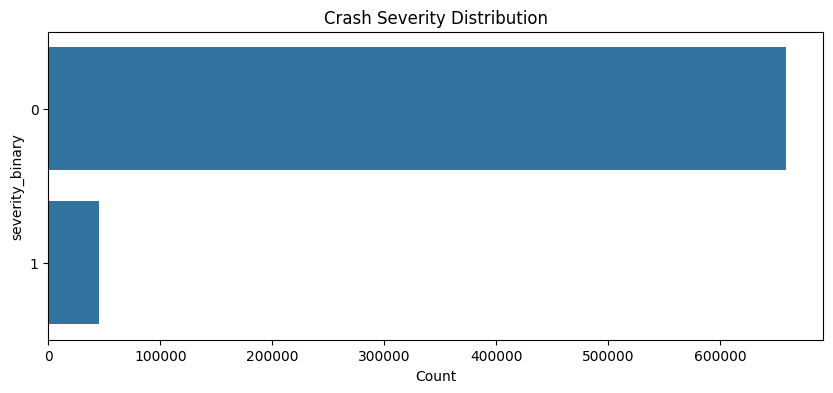

In [24]:
show_countplot(df, "severity_binary", "Crash Severity Distribution", (10,4))


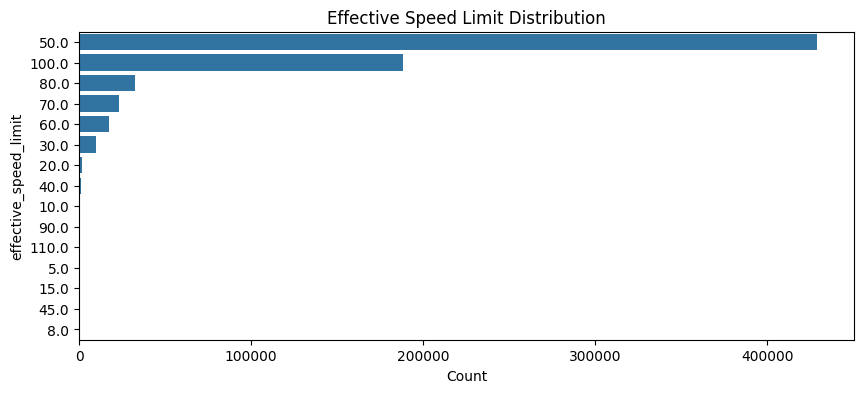

In [25]:
show_countplot(df, "effective_speed_limit", "Effective Speed Limit Distribution", (10,4))


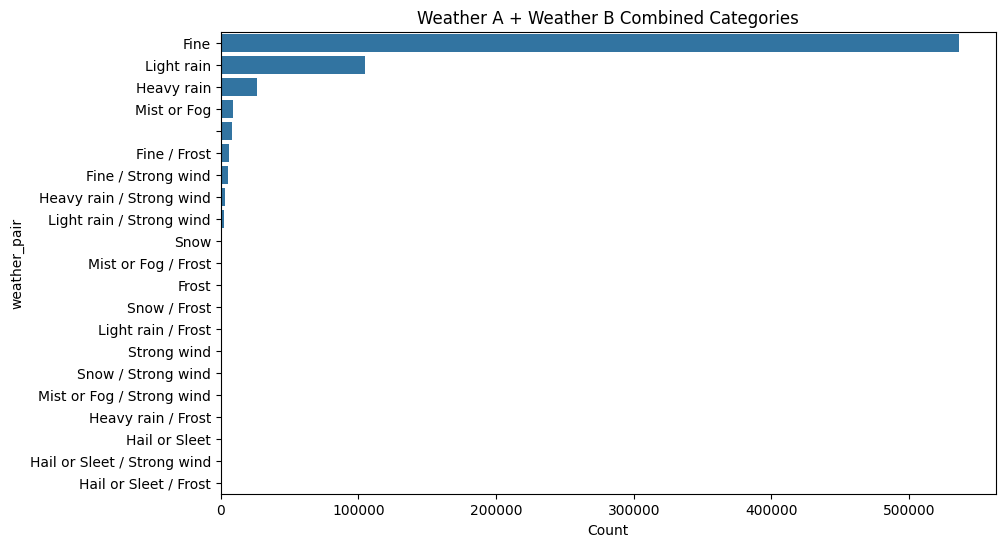

In [26]:
show_countplot(df, "weather_pair", "Weather A + Weather B Combined Categories", (10,6))


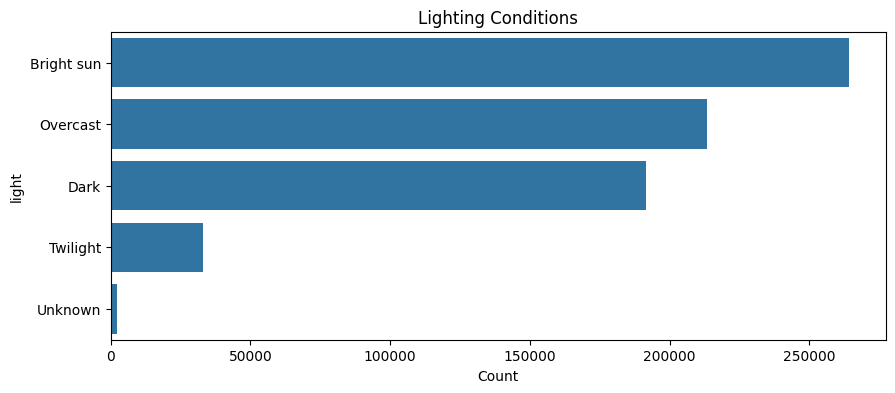

In [27]:
show_countplot(df, "light", "Lighting Conditions", (10,4))


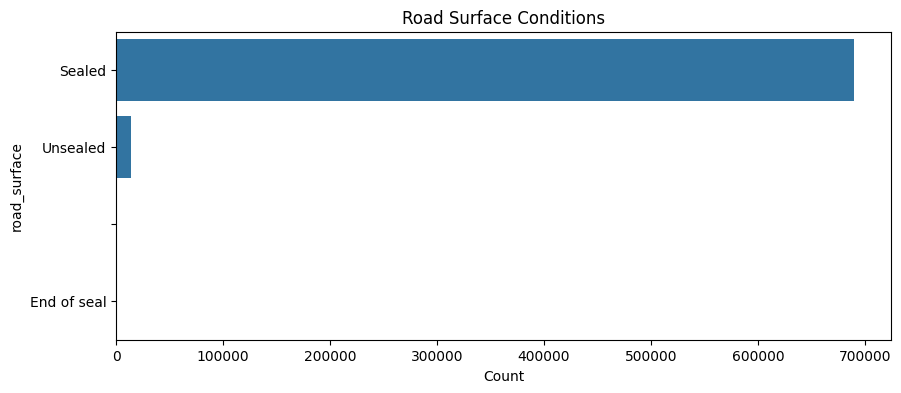

In [28]:
show_countplot(df, "road_surface", "Road Surface Conditions", (10,4))


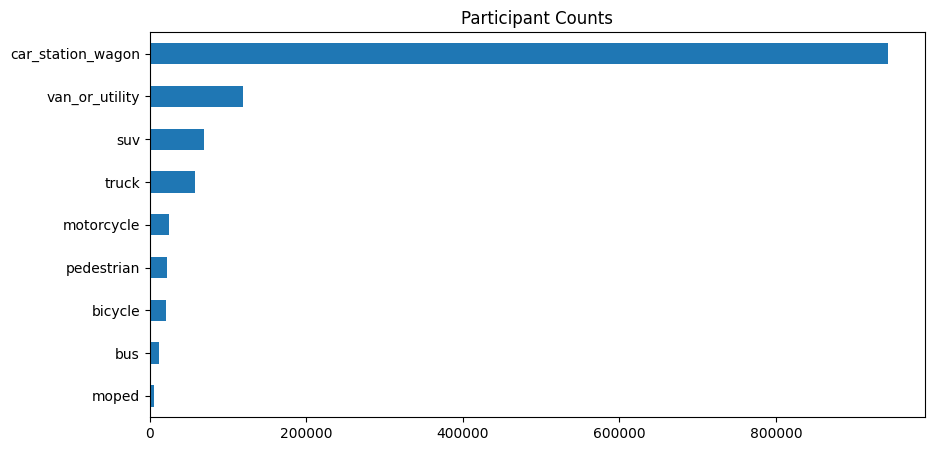

In [29]:
plt.figure(figsize=(10,5))
df[participant_cols].sum().sort_values().plot(kind="barh")
plt.title("Participant Counts")
plt.show()


# Bivariate EDA

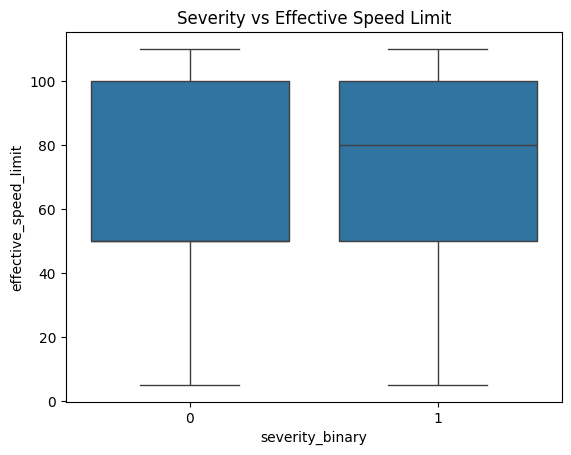

In [30]:
sns.boxplot(data=df, x="severity_binary", y="effective_speed_limit")
plt.title("Severity vs Effective Speed Limit")
plt.show()


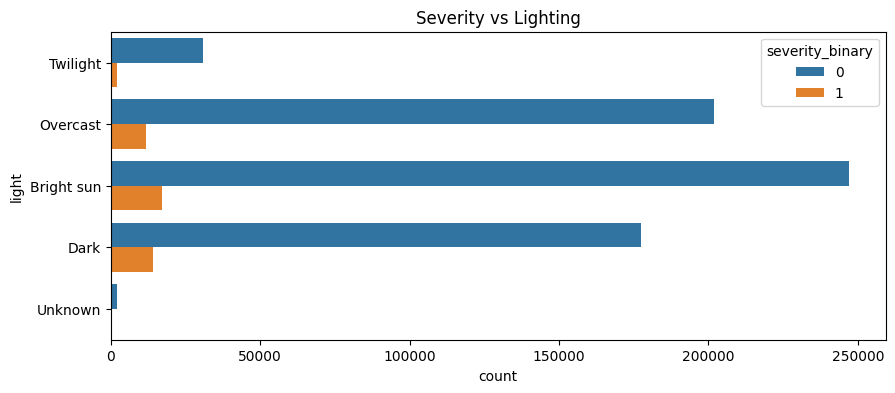

In [31]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, y="light", hue="severity_binary")
plt.title("Severity vs Lighting")
plt.show()


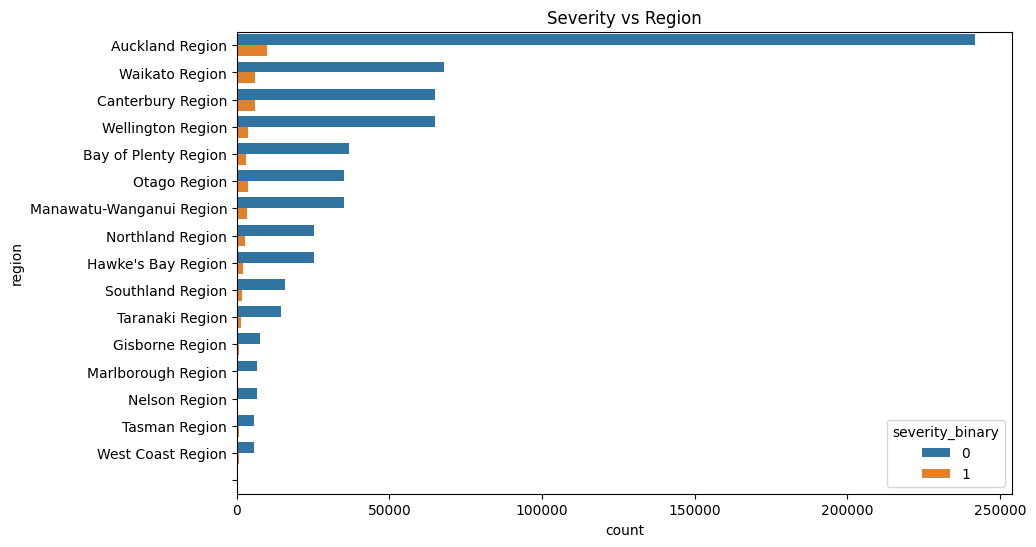

In [32]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y="region", hue="severity_binary",
              order=df["region"].value_counts().index)
plt.title("Severity vs Region")
plt.show()


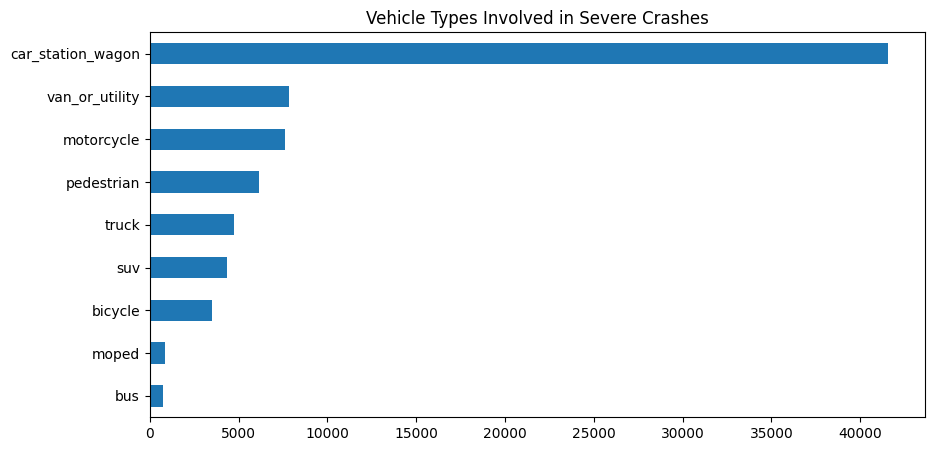

In [33]:
plt.figure(figsize=(10,5))
(df[participant_cols].multiply(df["severity_binary"], axis=0)
 .sum()
 .sort_values()
 .plot(kind="barh"))
plt.title("Vehicle Types Involved in Severe Crashes")
plt.show()


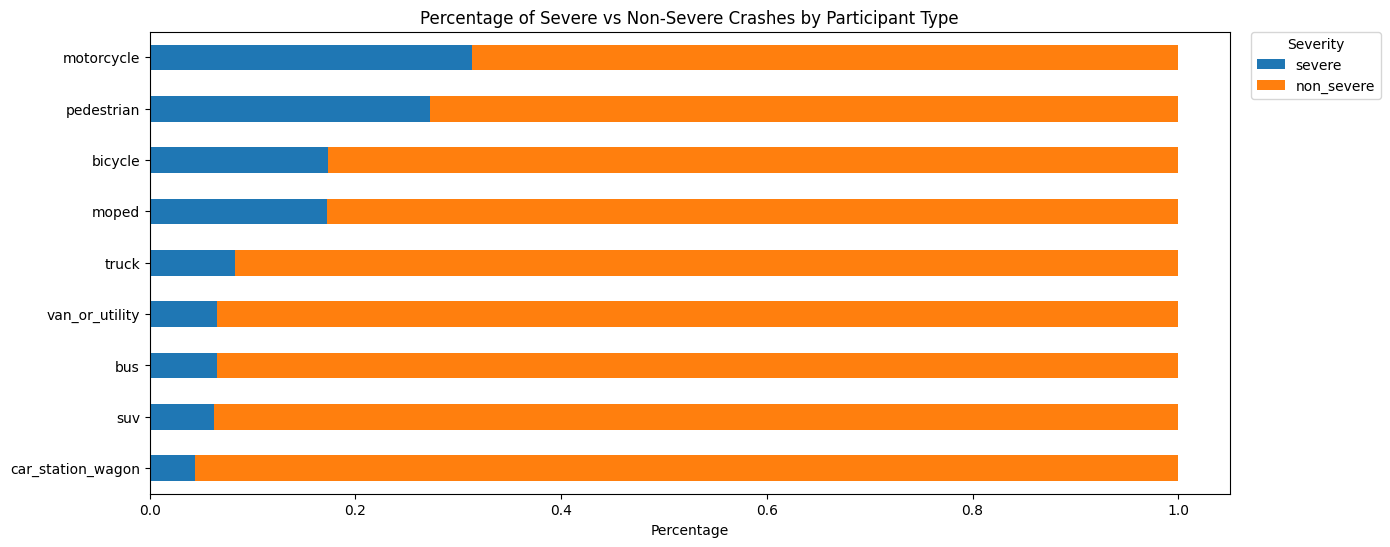

In [34]:
counts = pd.DataFrame({
    "severe": df[participant_cols].multiply(df["severity_binary"], axis=0).sum(),
    "non_severe": df[participant_cols].multiply(1 - df["severity_binary"], axis=0).sum()
})

percent = counts.div(counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(16, 6))  # wider figure

percent.sort_values("severe").plot(
    kind="barh",
    stacked=True,
    ax=ax
)

plt.title("Percentage of Severe vs Non-Severe Crashes by Participant Type")
plt.xlabel("Percentage")

# Legend outside the plot, without squeezing the axes
ax.legend(
    title="Severity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.subplots_adjust(right=0.8)  # reserve space for the legend
plt.show()


## Correlation analysis

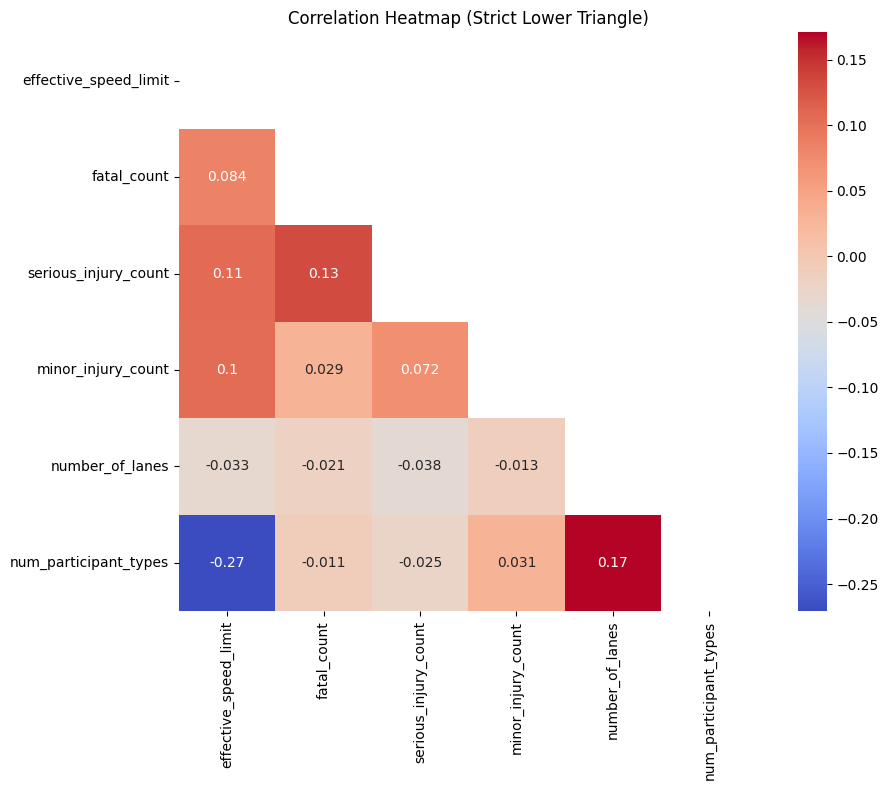

In [35]:
corr_cols = [
    "effective_speed_limit", "fatal_count",
    "serious_injury_count", "minor_injury_count",
    "number_of_lanes", "num_participant_types"
]

plot_lower_corr(df, corr_cols)


---


# Build the model

## Define features & train/test split

In [36]:
X = df[categorical_cols + numeric_cols]
y = df["severity_binary"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


## Preprocessing pipeline

In [37]:
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_cols),
        ("num", numeric_transformer, numeric_cols)
    ]
)


## Logistic regression

In [38]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", LogisticRegression(
            class_weight="balanced",
            C=1.0,
            solver="liblinear",
            max_iter=1000
        ))
    ]
)

lr_pipeline.fit(X_train, y_train)

# Predict probabilities for ROC-AUC
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

lr_results = evaluate_model(
    "Logistic Regression",
    lr_pipeline,
    X_test,
    y_test,
    y_proba=y_proba_lr
)

lr_results


=== Logistic Regression ===
Accuracy : 0.9999787030135235
Precision: 0.9997795900374697
Recall   : 0.9998897828722584
F1-score : 0.9998346834187469
ROC-AUC  : 0.9999423478417226

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    131792
           1       1.00      1.00      1.00      9073

    accuracy                           1.00    140865
   macro avg       1.00      1.00      1.00    140865
weighted avg       1.00      1.00      1.00    140865

Confusion matrix:
 [[131790      2]
 [     1   9072]]


{'model': 'Logistic Regression',
 'accuracy': 0.9999787030135235,
 'precision': 0.9997795900374697,
 'recall': 0.9998897828722584,
 'f1': 0.9998346834187469,
 'roc_auc': 0.9999423478417226,
 'classification_report': {'0': {'precision': 0.9999924122284526,
   'recall': 0.999984824572053,
   'f1-score': 0.9999886183858595,
   'support': 131792.0},
  '1': {'precision': 0.9997795900374697,
   'recall': 0.9998897828722584,
   'f1-score': 0.9998346834187469,
   'support': 9073.0},
  'accuracy': 0.9999787030135235,
  'macro avg': {'precision': 0.9998860011329611,
   'recall': 0.9999373037221557,
   'f1-score': 0.9999116509023032,
   'support': 140865.0},
  'weighted avg': {'precision': 0.9999787045243475,
   'recall': 0.9999787030135235,
   'f1-score': 0.9999787035599152,
   'support': 140865.0}},
 'confusion_matrix': array([[131790,      2],
        [     1,   9072]])}

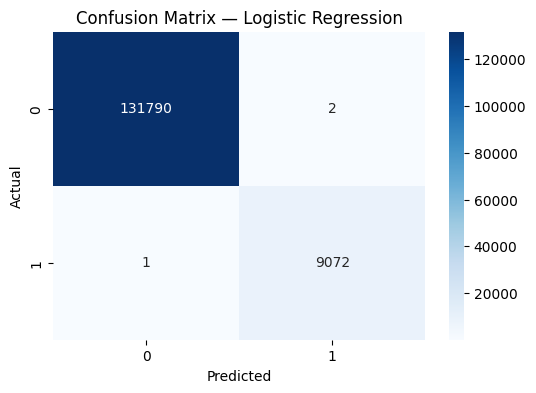

In [39]:
plot_confusion_matrix(lr_results["confusion_matrix"], title="Confusion Matrix — Logistic Regression")


## SVM

In [40]:
# Base linear SVM (no probability output)
svm_base = LinearSVC(
    class_weight="balanced",
    C=1.0,
    max_iter=5000
)

# Wrap in calibration to get predict_proba for ROC-AUC
svm_clf = CalibratedClassifierCV(
    svm_base,
    cv=3  # small, efficient calibration
)

svm_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", svm_clf)
    ]
)

svm_pipeline.fit(X_train, y_train)

# Probabilities for ROC-AUC
y_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

svm_results = evaluate_model(
    "Linear SVM (calibrated)",
    svm_pipeline,
    X_test,
    y_test,
    y_proba=y_proba_svm
)

svm_results


=== Linear SVM (calibrated) ===
Accuracy : 0.9999929010045079
Precision: 1.0
Recall   : 0.9998897828722584
F1-score : 0.999944888399008
ROC-AUC  : 0.9999743328200795

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    131792
           1       1.00      1.00      1.00      9073

    accuracy                           1.00    140865
   macro avg       1.00      1.00      1.00    140865
weighted avg       1.00      1.00      1.00    140865

Confusion matrix:
 [[131792      0]
 [     1   9072]]


{'model': 'Linear SVM (calibrated)',
 'accuracy': 0.9999929010045079,
 'precision': 1.0,
 'recall': 0.9998897828722584,
 'f1': 0.999944888399008,
 'roc_auc': 0.9999743328200795,
 'classification_report': {'0': {'precision': 0.9999924123435995,
   'recall': 1.0,
   'f1-score': 0.9999962061574065,
   'support': 131792.0},
  '1': {'precision': 1.0,
   'recall': 0.9998897828722584,
   'f1-score': 0.999944888399008,
   'support': 9073.0},
  'accuracy': 0.9999929010045079,
  'macro avg': {'precision': 0.9999962061717997,
   'recall': 0.9999448914361292,
   'f1-score': 0.9999705472782072,
   'support': 140865.0},
  'weighted avg': {'precision': 0.9999929010583726,
   'recall': 0.9999929010045079,
   'f1-score': 0.9999929008223555,
   'support': 140865.0}},
 'confusion_matrix': array([[131792,      0],
        [     1,   9072]])}

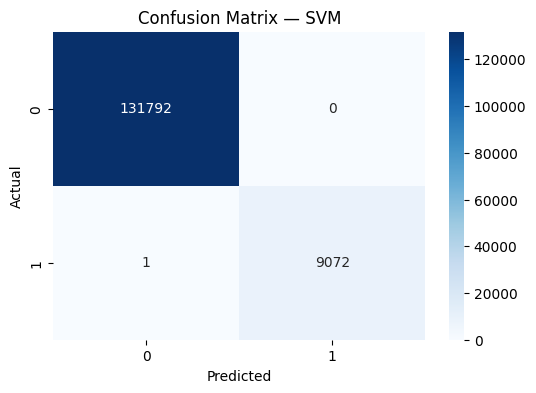

In [41]:
plot_confusion_matrix(svm_results["confusion_matrix"], title="Confusion Matrix — SVM")


## Naïve Bayes

Why BernoulliNB, rather than GaussianNB, is the right choice here

1. One‑hot encoded features are binary. BernoulliNB is designed for this structure.

2. It handles sparse matrices efficiently. GaussianNB forces dense arrays, which is slow and memory‑heavy.

3. It’s extremely fast. We get results faster.

4. It gives calibrated probabilities natively. No need for wrappers or extra steps.

In [42]:
nb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", BernoulliNB())
    ]
)

nb_pipeline.fit(X_train, y_train)

# Probabilities for ROC-AUC
y_proba_nb = nb_pipeline.predict_proba(X_test)[:, 1]

nb_results = evaluate_model(
    "Naïve Bayes (Bernoulli)",
    nb_pipeline,
    X_test,
    y_test,
    y_proba=y_proba_nb
)

nb_results


=== Naïve Bayes (Bernoulli) ===
Accuracy : 0.9975011535867675
Precision: 0.9627507163323782
Recall   : 0.9998897828722584
F1-score : 0.9809688581314879
ROC-AUC  : 0.9999550758493079

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    131792
           1       0.96      1.00      0.98      9073

    accuracy                           1.00    140865
   macro avg       0.98      1.00      0.99    140865
weighted avg       1.00      1.00      1.00    140865

Confusion matrix:
 [[131441    351]
 [     1   9072]]


{'model': 'Naïve Bayes (Bernoulli)',
 'accuracy': 0.9975011535867675,
 'precision': 0.9627507163323782,
 'recall': 0.9998897828722584,
 'f1': 0.9809688581314879,
 'roc_auc': 0.9999550758493079,
 'classification_report': {'0': {'precision': 0.9999923920816786,
   'recall': 0.9973367123952895,
   'f1-score': 0.99866278672208,
   'support': 131792.0},
  '1': {'precision': 0.9627507163323782,
   'recall': 0.9998897828722584,
   'f1-score': 0.9809688581314879,
   'support': 9073.0},
  'accuracy': 0.9975011535867675,
  'macro avg': {'precision': 0.9813715542070284,
   'recall': 0.9986132476337739,
   'f1-score': 0.9898158224267839,
   'support': 140865.0},
  'weighted avg': {'precision': 0.9975936860576599,
   'recall': 0.9975011535867675,
   'f1-score': 0.9975231351826455,
   'support': 140865.0}},
 'confusion_matrix': array([[131441,    351],
        [     1,   9072]])}

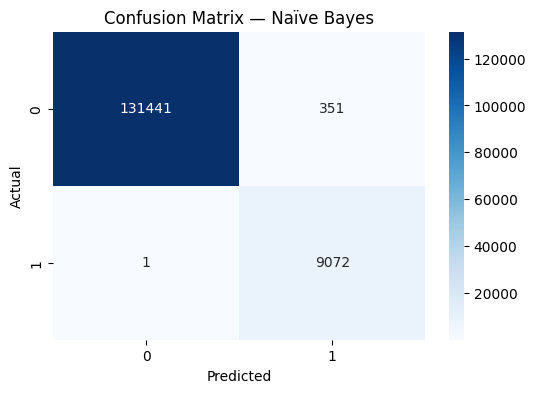

In [43]:
plot_confusion_matrix(nb_results["confusion_matrix"], title="Confusion Matrix — Naïve Bayes")


---


# Machine learning Comparison

In [44]:
results_df = pd.DataFrame([lr_results, svm_results, nb_results])
summary_df = summarise_model_results(results_df)
numeric_cols = summary_df.select_dtypes(include="number").columns
summary_df.style.format({col: "{:.6f}" for col in numeric_cols})


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.999979,0.999780,0.999890,0.999835,0.999942
1,Linear SVM (calibrated),0.999993,1.000000,0.999890,0.999945,0.999974
2,Naïve Bayes (Bernoulli),0.997501,0.962751,0.999890,0.980969,0.999955


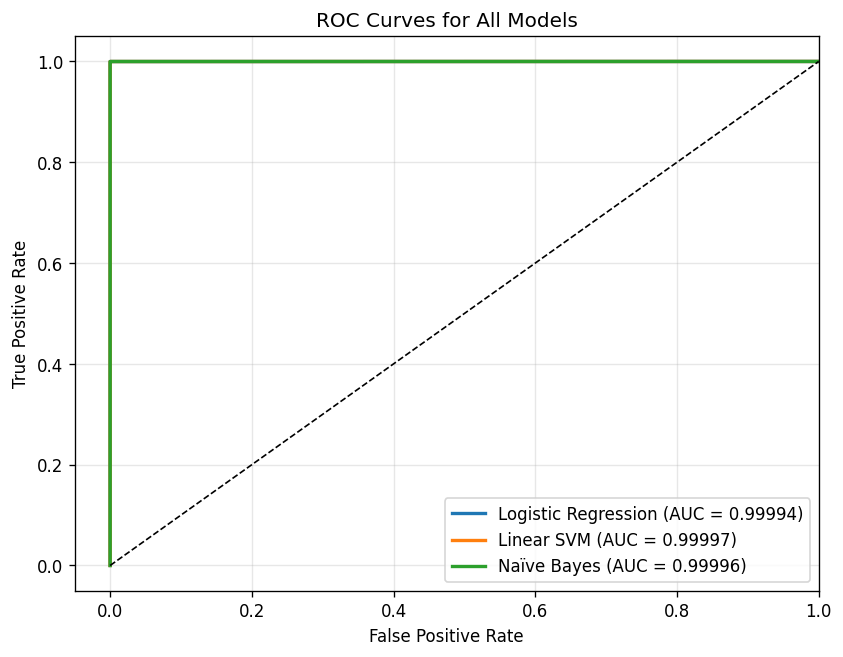

In [45]:
plt.figure(figsize=(8, 6), dpi=120)

# LR
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.5f})", linewidth=2)

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f"Linear SVM (AUC = {auc_svm:.5f})", linewidth=2)

# NB
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, label=f"Naïve Bayes (AUC = {auc_nb:.5f})", linewidth=2)

# Diagonal reference line
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlim([-0.05, 1.0])
plt.ylim([-0.05, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()


## Summary of Findings

The analysis reveals several consistent drivers of severe crashes. Higher speed zones, poor lighting, complex road geometry, and multi‑vehicle involvement all show strong associations with severity, and the engineered feature set captures these relationships cleanly. The exploratory plots reinforce these patterns and make the risk factors intuitive to communicate.

Across the three models tested, the calibrated Linear SVM delivers the strongest overall performance, achieving near‑perfect accuracy and recall on the imbalanced dataset. Logistic Regression follows closely, offering a highly interpretable and stable baseline. Bernoulli Naive Bayes underperforms relative to the others due to its binary‑feature assumptions, which do not align with the predominantly integer and categorical structure of the dataset.

Overall, the results show that even simple linear models can extract meaningful predictive structure from the data, providing a defensible baseline for understanding and anticipating severe crash risk — and a solid foundation for future refinement or more advanced modelling.
